In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable, axes_size
import seaborn as sns
import scanpy as sc
import anndata as an
import scanpy.external as sce
import time

from importlib import reload

sc.settings.verbosity = 3 

In [2]:
fpath = "/scratch/indikar_root/indikar1/shared_data/single_cell_fibroblast/scanpy/processed.anndata.h5ad"
adata = sc.read_h5ad(fpath)
sc.logging.print_memory_usage()
print(adata)

Memory usage: current 2.67 GB, difference +2.67 GB
AnnData object with n_obs × n_vars = 7748 × 14082
    obs: 'n_genes', 'cell', 'G1', 'G2M', 'S', 'pred_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'pred_G1', 'pred_S', 'pred_G2M', 'dpt_pseudotime'
    var: 'gene_name', 'Chromosome', 'Start', 'End', 'Strand', 'seurat_S', 'seurat_G2M', 'is_seurat', 'is_kegg', 'whitfield_G1/S', 'whitfield_G2', 'whitfield_G2/M', 'whitfield_M/G1', 'whitfield_S', 'is_whitfield', 'GO_G1', 'GO_G1/S', 'GO_G2', 'GO_G2/M', 'GO_M', 'GO_S', 'is_GO', 'LIU_G2MvsG0G1', 'LIU_G2MvsS', 'LIU_SvsG0G1', 'is_LIU', 'cell_cycle', 'n_cells', 'mt', 'ribo', 'hb', 'n

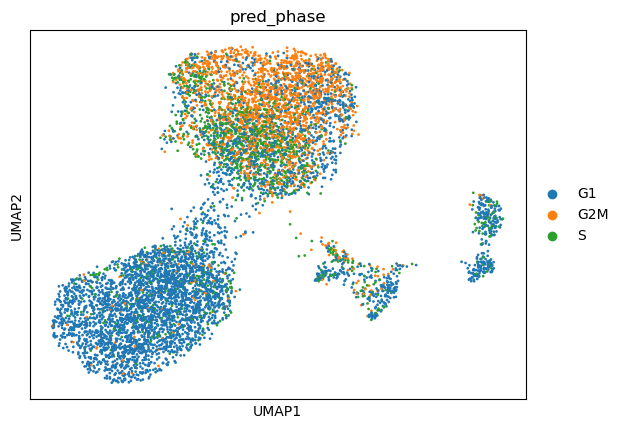

In [3]:

sc.pl.umap(
    adata, 
    color=[
        'pred_phase',
    ],
    ncols=1,
)

In [4]:
adata.obs[['G1', 'G2M', 'S', 'pred_phase']].head()

,G1,G2M,S,pred_phase
cell_id,,,,
AAACCAAAGGGTAGCA,80.0,403.0,87.0,G2M
AAACCAAAGTAAGGGT,18.0,5.0,7.0,G1
AAACCATTCAGGTAGG,43.0,183.0,59.0,G2M
AAACCATTCCAGCCCT,229.0,43.0,1872.0,S
AAACCATTCGTGACCG,58.0,1.0,2.0,G1


In [9]:
adata.obsp['connectivities'].shape

(7748, 7748)

In [8]:
adata

AnnData object with n_obs × n_vars = 7748 × 14082
    obs: 'n_genes', 'cell', 'G1', 'G2M', 'S', 'pred_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'pred_G1', 'pred_S', 'pred_G2M', 'dpt_pseudotime'
    var: 'gene_name', 'Chromosome', 'Start', 'End', 'Strand', 'seurat_S', 'seurat_G2M', 'is_seurat', 'is_kegg', 'whitfield_G1/S', 'whitfield_G2', 'whitfield_G2/M', 'whitfield_M/G1', 'whitfield_S', 'is_whitfield', 'GO_G1', 'GO_G1/S', 'GO_G2', 'GO_G2/M', 'GO_M', 'GO_S', 'is_GO', 'LIU_G2MvsG0G1', 'LIU_G2MvsS', 'LIU_SvsG0G1', 'is_LIU', 'cell_cycle', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_count

In [11]:
adata.var.columns

Index(['gene_name', 'Chromosome', 'Start', 'End', 'Strand', 'seurat_S',
       'seurat_G2M', 'is_seurat', 'is_kegg', 'whitfield_G1/S', 'whitfield_G2',
       'whitfield_G2/M', 'whitfield_M/G1', 'whitfield_S', 'is_whitfield',
       'GO_G1', 'GO_G1/S', 'GO_G2', 'GO_G2/M', 'GO_M', 'GO_S', 'is_GO',
       'LIU_G2MvsG0G1', 'LIU_G2MvsS', 'LIU_SvsG0G1', 'is_LIU', 'cell_cycle',
       'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts',
       'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts',
       'log1p_total_counts', 'highly_variable', 'means', 'dispersions',
       'dispersions_norm'],
      dtype='object')